# Perceptron 2D

## Classe Perceptron

In [1]:
from dataclasses import dataclass

@dataclass
class Perceptron2D:
    w0: float # biais
    w1: float
    w2: float

    def __repr__(self):
        return f"Perceptron ({self.w0, self.w1, self.w2})"
    # SKIP
    def output(self, x1, x2):
        if x1 * self.w1 + x2 * self.w2 - self.w0 >= 0:
            return 1
        else:
            return 0


    def learn(self, x1, x2, t, r):
        y = self.output(x1, x2)
        if y != t:
            self.w0 = self.w0 + r * (t - y) * (-1)
            self.w1 = self.w1 + r * (t - y) * x1
            self.w2 = self.w2 + r * (t - y) * x2


## Utilitaires d'affichage

In [31]:
import matplotlib.pyplot as plt
import numpy as np


def make_axis():
    fig, ax = plt.subplots()
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.grid()
    return ax

    
def display_plane(ax, p: Perceptron):
    """Affiche la droite de séparation et colorie les demi-plans.
    
    Bleu : demi-plan où le perceptron sort 1.
    Orange : demi-plan où le perceptron sort 0.
    """

    # Grille pour colorier les demi-plans
    xx, yy = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    zz = (xx * p.w1 + yy * p.w2 - p.w0 >= 0).astype(int)
    # 1 -> bleu, 0 -> orange
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=['tab:orange', 'tab:blue'], alpha=0.1)
    # Droite de séparation : w1*x1 + w2*x2 - w0 = 0
    if p.w2 != 0:
        ax.axline((0, p.w0 / p.w2), (1, (p.w0 - p.w1) / p.w2), color='black', linewidth=2)
    elif p.w1 != 0:
        ax.axvline(p.w0 / p.w1, color='black', linewidth=2)

## Classe TrainPoint

In [32]:
@dataclass
class TrainPoint:
    x1: float
    x2: float
    t: int

In [33]:
train_1 = [
    TrainPoint(*v) 
    for v in [
        (1, 1, 1),
        (0, 1, 1),
        (1, 0, 1),
        (0, 0, 0)
    ]
]

In [34]:
def display_train(ax, points: list[TrainPoint]):
    blue = []
    orange = []
    for p in points:
        if p.t == 1:
            blue.append( ( p.x1, p.x2) )
        else:
            orange.append( (p.x1, p.x2) )
    ax.plot(
        *zip(*blue),
        "o",
        color="blue"
    )

    ax.plot(
        *zip(*orange),
        "o",
        color="orange"
    )

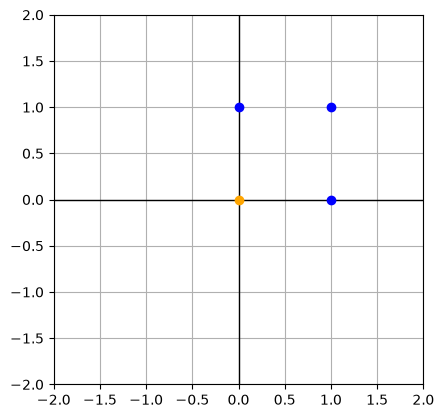

In [35]:
ax = make_axis()
display_train(ax, train_1)

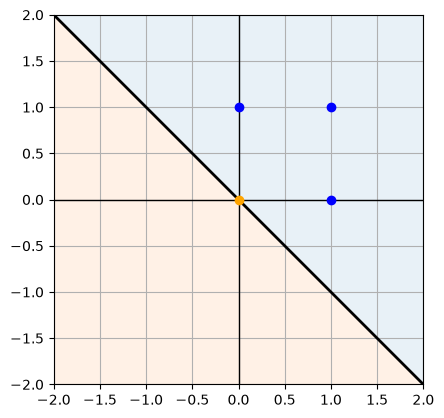

In [141]:
ax = make_axis()

display_plane(ax, Perceptron(0,1,1))
display_train(ax, train_1)

In [142]:
train_and = [
    TrainPoint(*v) 
    for v in [
        (1, 1, 1),
        (0, 1, 0),
        (1, 0, 0),
        (0, 0, 0)
    ]
]

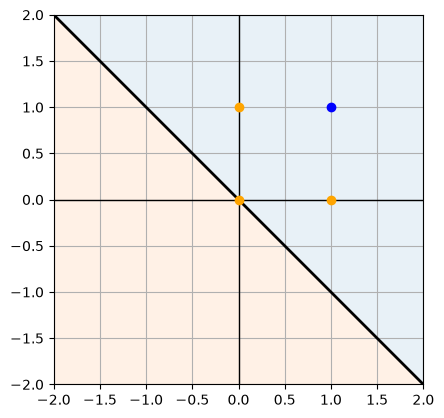

In [143]:
ax = make_axis()
perceptron = Perceptron(0,1,1)
display_plane(ax, perceptron)
display_train(ax, train_and)

In [144]:
perceptron

Perceptron ((0, 1, 1))

In [154]:
for p in train_and:
    perceptron.learn(p.x1, p.x2, p.t, 0.1)
perceptron

Perceptron ((0.7999999999999999, 0.6000000000000001, 0.6000000000000001))

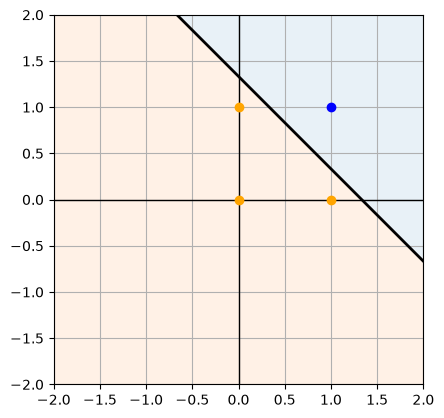

In [155]:
ax = make_axis()
display_plane(ax, perceptron)
display_train(ax, train_and)

In [156]:
train_rot = [
    TrainPoint(*v) 
    for v in [
        (-1, -1, 1),
        (1, 1, 0),
    ]
]

In [185]:
perceptron = Perceptron(0,1,1)

In [186]:
for p in train_rot:
    perceptron.learn(p.x1, p.x2, p.t, 0.1)
perceptron

Perceptron ((0.0, 0.8, 0.8))

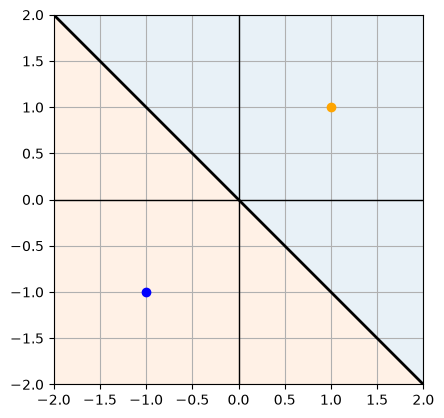

In [187]:
ax = make_axis()
display_plane(ax, perceptron)
display_train(ax, train_rot)

In [16]:
train_sep = [
    TrainPoint(*v) 
    for v in [
        (-1.5, 0.2, 1),
        (-1, 0.5, 1),
        (-0.5, 1, 1),
        
        (-1.5, -1, 0),
        (-1, -0.6, 0),
        (-0.5, 0, 0),
        
    ]
]
perceptron = Perceptron(0,0,0)

In [22]:
for p in train_sep:
    perceptron.learn(p.x1, p.x2, p.t, 10)
perceptron
#ax = make_axis()
# display_plane(ax, perceptron)
#display_train(ax, train_sep)

Perceptron ((10, -5.0, 26.0))

# Perceptron

Implémentation en dimension quelconque avec numpy

In [65]:
from dataclasses import dataclass
import numpy as np

@dataclass
class Perceptron:
    w: np.array
    
    def __repr__(self):
        return f"Perceptron ({self.w})"

    # SKIP
    def output(self, x: np.array):
        s = np.dot(self.w, x)
        if s >= 0:
            return 1
        else:
            return 0


    def learn(self, x: np.array, t: float):
        
        x_full = np.insert(x, 0, -1)
        r = 0.1
        y = self.output(x_full)
        print(self.w)
        print(x_full)
        if y != t:
            self.w = self.w + r * (t - y) * x_full


In [66]:
Perceptron( np.array([1,1,1]))

Perceptron ([1 1 1])